# UBER DATA ANALYSIS PROJECT 
### EDA & Business insights

#### Analyze Uber ride data to identify patterns in trip behavior, demand times, and usage trends.


Ride-sharing companies collect lots of data but struggle to use it effectively. This creates problems:
 
- **Poor resource planning** - Drivers aren't in the right place at the right time
- **Missed opportunities** - Can't identify the best times and routes for higher earnings
- **Incomplete data** - Missing information makes it hard to understand customer needs
- **No clear metrics** - Difficult to measure performance and improvement

# 1. Load the dataset and libraries

In [33]:
# Import core libraries for data analysis and visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# Plot style
sns.set_theme(style="whitegrid", font_scale=1.0)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlepad": 10,
})

# Colour constants (used throughout for consistency)
BIZ    = "#2563EB"   # Business trips - blue
PERS   = "#F97316"   # Personal trips - orange
ACCENT = "#16A34A"   # Highlight  - green

print("Libraries loaded successfully.")


Libraries loaded successfully.


In [34]:
# Load the Uber trips CSV file
df = pd.read_csv("../dataset/UberDataset.csv")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Shape: 1,155 rows × 7 columns


,START_DATE,END_DATE,CATEGORY,START,STOP,MILES,PURPOSE
0,01-01-2016 21.11,01-01-2016 21.17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 1.25,01-02-2016 1.37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20.25,01-02-2016 20.38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17.31,01-05-2016 17.45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14.42,01-06-2016 15.49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


# 2. Basic info

In [35]:
# Column names, data types, and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1155 entries, 0 to 1154
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   START_DATE  1155 non-null   object 
 1   END_DATE    1155 non-null   object 
 2   CATEGORY    1155 non-null   object 
 3   START       1155 non-null   object 
 4   STOP        1155 non-null   object 
 5   MILES       1155 non-null   float64
 6   PURPOSE     653 non-null    object 
dtypes: float64(1), object(6)
memory usage: 63.3+ KB


In [36]:
df.describe() #summary statistics

,MILES
count,1155.000000
mean,10.566840
std,21.579106
min,0.500000
25%,2.900000
50%,6.000000
75%,10.400000
max,310.300000


# 3. Data Cleaning

### 3.1 Column Renaming
Standardise all column names to lowercase for consistency.

In [37]:
df.columns = df.columns.str.lower()
df.head()

,start_date,end_date,category,start,stop,miles,purpose
0,01-01-2016 21.11,01-01-2016 21.17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,01-02-2016 1.25,01-02-2016 1.37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,01-02-2016 20.25,01-02-2016 20.38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,01-05-2016 17.31,01-05-2016 17.45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,01-06-2016 14.42,01-06-2016 15.49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


### 3.2 Date Parsing

The raw date strings use a non-standard format: `01-01-2016 21.11`  (dots instead of colons for time, slashes sometimes mixed in).

A single reusable function handles the fix for both `start_date` and `end_date`.


In [38]:
def clean_dates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Normalise date strings in START_DATE and END_DATE columns and parse to datetime.
    Raw format example: '01-01-2016 21.11'  →  parsed as 2016-01-01 21:11
    """
    for col in ["start_date", "end_date"]:
        df[col] = (
            df[col]
            .str.replace(".", ":", regex=False)   # fix time separator
            .str.replace("/", "-", regex=False)   # normalise date separator
        )
        df[col] = pd.to_datetime(df[col], dayfirst=False, errors="coerce")
    return df

df = clean_dates(df)
print("Parsed date range:", df["start_date"].min(), "->", df["start_date"].max())
df[["start_date", "end_date"]].head(3)


Parsed date range: 2016-01-01 21:11:00 -> 2016-12-31 22:08:00


,start_date,end_date
0,2016-01-01 21:11:00,2016-01-01 21:17:00
1,2016-01-02 01:25:00,2016-01-02 01:37:00
2,2016-01-02 20:25:00,2016-01-02 20:38:00


### 3.3 Duplicates removal

In [39]:
before = len(df)
df.drop_duplicates(inplace=True)
after  = len(df)
print(f"Rows removed: {before - after} duplicate(s) -> {after:,} clean rows remain.")

Rows removed: 1 duplicate(s) -> 1,154 clean rows remain.


### 3.4 Data Quality Audit

Before any analysis, understand what's missing and how severe it is.

In [40]:
null_summary = pd.DataFrame({
    "Missing count" : df.isnull().sum(),
    "Missing %"     : (df.isnull().mean() * 100).round(1),
}).sort_values("Missing %", ascending=False)

print(null_summary[null_summary["Missing count"] > 0].to_string())

         Missing count  Missing %
purpose            502       43.5


> **Data quality note:** `purpose` has **502 missing values (43.5%)**.
> This is the single biggest limitation of this dataset. All purpose-based analysis is scoped to the 652 trips where purpose is known, and findings are flagged accordingly.


# 4. Feature Engineering
Derived columns used across the analysis.

In [41]:
#  Temporal features 
df["hour"]      = df["start_date"].dt.hour
df["weekday"]   = df["start_date"].dt.day_name()
df["month"]     = df["start_date"].dt.month_name()
df["month_num"] = df["start_date"].dt.month

# Time-of-day label 
def assign_time_of_day(hour: int) -> str:
    """Map hour (0–23) to a named time-of-day band."""
    if 5  <= hour < 12: return "Morning"
    if 12 <= hour < 17: return "Afternoon"
    if 17 <= hour < 21: return "Evening"
    return "Night"

# trip duration in minutes
df['duration'] = (df['end_date'] - df['start_date']).dt.total_seconds() / 60

df["time_of_day"] = df["hour"].apply(assign_time_of_day)

#  Route 
df["route"] = (
    df["start"].fillna("Unknown") + " -> " + df["stop"].fillna("Unknown")
)

#  Journey type 
df["same_city"] = df["start"] == df["stop"]   # intra-city vs inter-city

#  Purpose with placeholder 
df["purpose_clean"] = df["purpose"].fillna("Not Recorded")

#  Outlier flag (IQR method on miles) 
Q1 = df["miles"].quantile(0.25)
Q3 = df["miles"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df["is_outlier"] = df["miles"] > upper_bound

print("Feature engineering complete.")
print(df[["hour","weekday","month","time_of_day","route","same_city","is_outlier"]].head(3).to_string())

Feature engineering complete.
   hour   weekday    month time_of_day                       route  same_city  is_outlier
0    21    Friday  January       Night  Fort Pierce -> Fort Pierce       True       False
1     1  Saturday  January       Night  Fort Pierce -> Fort Pierce       True       False
2    20  Saturday  January     Evening  Fort Pierce -> Fort Pierce       True       False


In [42]:
df.head() 

,start_date,end_date,category,start,stop,miles,purpose,hour,weekday,month,month_num,duration,time_of_day,route,same_city,purpose_clean,is_outlier
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,21,Friday,January,1,6.0,Night,Fort Pierce -> Fort Pierce,True,Meal/Entertain,False
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NaN,1,Saturday,January,1,12.0,Night,Fort Pierce -> Fort Pierce,True,Not Recorded,False
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,20,Saturday,January,1,13.0,Evening,Fort Pierce -> Fort Pierce,True,Errand/Supplies,False
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,17,Tuesday,January,1,14.0,Evening,Fort Pierce -> Fort Pierce,True,Meeting,False
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,14,Wednesday,January,1,67.0,Afternoon,Fort Pierce -> West Palm Beach,False,Customer Visit,True


# 5.  Executive Summary

Key metrics computed before diving into individual analyses.

In [43]:
WKDAY_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
MONTH_ORDER = ["January","February","March","April","May","June",
               "July","August","September","October","November","December"]
TOD_ORDER   = ["Morning","Afternoon","Evening","Night"]

# Core metrics
total_trips     = len(df)
avg_miles       = df["miles"].mean()
median_miles    = df["miles"].median()
avg_duration    = df["duration"].mean()
pct_business    = (df["category"] == "Business").mean() * 100
pct_missing_pur = df["purpose"].isna().mean() * 100
top_purpose     = df["purpose"].value_counts().idxmax()
top_month       = df["month"].value_counts().idxmax()
top_day         = df["weekday"].value_counts().idxmax()
top_route_val   = df[~df["route"].str.contains("Unknown")]["route"].value_counts()
top_route       = top_route_val.index[0]
outlier_count   = df["is_outlier"].sum()

print("=" * 45)
print(f"  Total trips analysed    : {total_trips:,}")
print(f"  Average trip distance   : {avg_miles:.2f} miles")
print(f"  Median trip distance    : {median_miles:.1f} miles")
print(f"  Average trip duration   : {avg_duration:.1f} minutes")
print(f"  Business share          : {pct_business:.1f}%")
print(f"  Purpose data missing    : {pct_missing_pur:.1f}%")
print(f"  Most common purpose     : {top_purpose}")
print(f"  Busiest month           : {top_month}")
print(f"  Busiest weekday         : {top_day}")
print(f"  Top route               : {top_route} ({top_route_val.iloc[0]} trips)")
print(f"  Outlier trips (IQR)     : {outlier_count}")
print("=" * 45)


  Total trips analysed    : 1,154
  Average trip distance   : 10.57 miles
  Median trip distance    : 6.0 miles
  Average trip duration   : 23.2 minutes
  Business share          : 93.3%
  Purpose data missing    : 43.5%
  Most common purpose     : Meeting
  Busiest month           : December
  Busiest weekday         : Friday
  Top route               : Morrisville -> Cary (75 trips)
  Outlier trips (IQR)     : 77


# 6. Temporal Analysis

### 6.1 Monthly Trip Volume

How does demand fluctuate across the year? We plot raw trip counts and overlay a linear trend line.


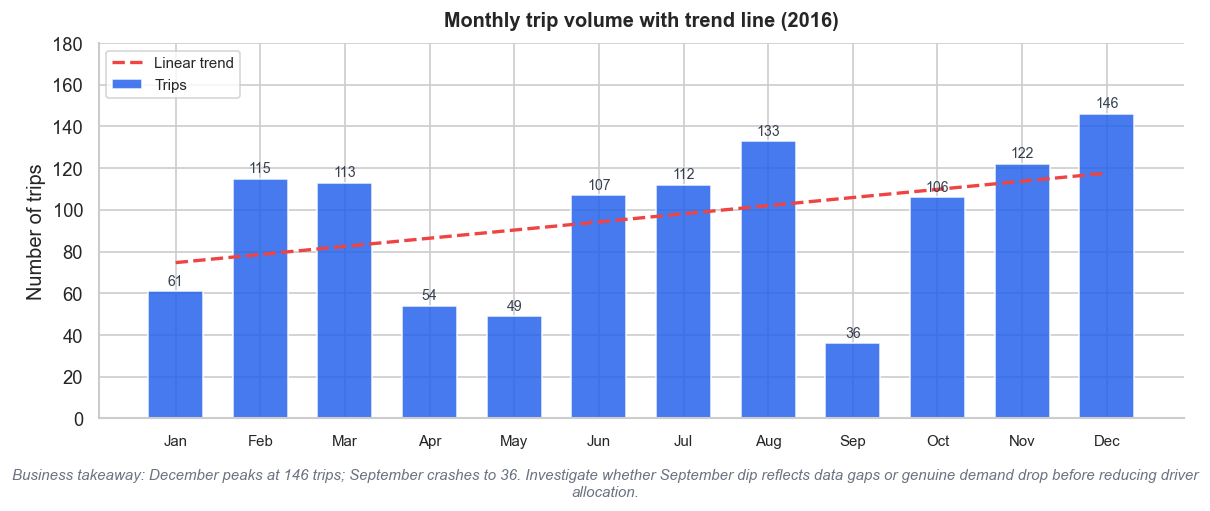

In [44]:
monthly = (
    df.groupby(["month_num", "month"])
      .size()
      .reset_index(name="trips")
      .sort_values("month_num")
)

# Linear trend
z = np.polyfit(monthly["month_num"], monthly["trips"], 1)
trend_fn = np.poly1d(z)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly["month_num"], monthly["trips"],
       color=BIZ, alpha=0.85, width=0.65, zorder=2, label="Trips")
ax.plot(monthly["month_num"], trend_fn(monthly["month_num"]),
        "--", color="#EF4444", lw=2, zorder=3, label="Linear trend")

# Labels
for _, row in monthly.iterrows():
    ax.text(row["month_num"], row["trips"] + 1.5, str(row["trips"]),
            ha="center", va="bottom", fontsize=8.5, color="#374151")

ax.set_xticks(monthly["month_num"])
ax.set_xticklabels([m[:3] for m in monthly["month"]], fontsize=9)
ax.set_ylim(0, 180)
ax.set_ylabel("Number of trips")
ax.set_title("Monthly trip volume with trend line (2016)", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)

fig.text(
    0.5, -0.05,
    "Business takeaway: December peaks at 146 trips; September crashes to 36. "
    "Investigate whether September dip reflects data gaps or genuine demand drop before reducing driver allocation.",
    ha="center", fontsize=9, color="#6B7280", style="italic", wrap=True
)
plt.tight_layout()
plt.savefig("F:/jybooks/uber-ride-analytics-using-python/images/monthly_trip_volume.png", dpi=120, bbox_inches="tight") #saving png
plt.show()


### 6.2 Weekday Demand - Business vs Personal

Are Business and Personal trips concentrated on different days?

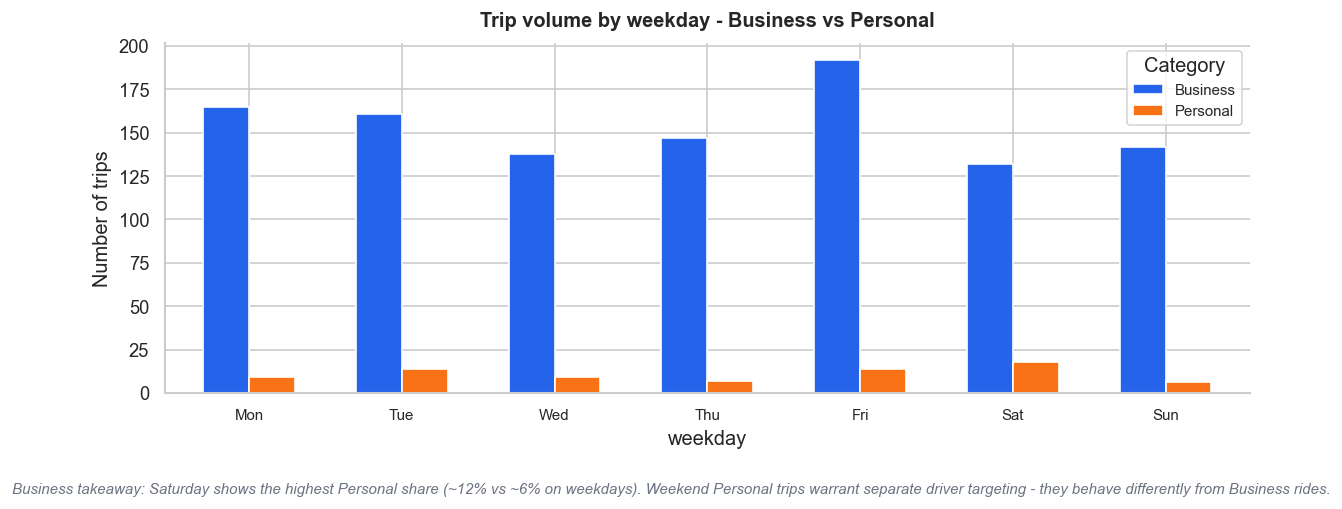

In [45]:
wkday_cat = (
    df.groupby(["weekday", "category"])
      .size()
      .reset_index(name="count")
)
wkday_cat["weekday"] = pd.Categorical(wkday_cat["weekday"], categories=WKDAY_ORDER, ordered=True)
wkday_piv = (
    wkday_cat.sort_values("weekday")
             .pivot(index="weekday", columns="category", values="count")
             .fillna(0)
)

fig, ax = plt.subplots(figsize=(10, 4))
wkday_piv.plot(kind="bar", ax=ax, color=[BIZ, PERS], width=0.6, zorder=2)
ax.set_xticklabels([d[:3] for d in WKDAY_ORDER], rotation=0, fontsize=9)
ax.set_ylabel("Number of trips")
ax.set_title("Trip volume by weekday - Business vs Personal", fontsize=12, fontweight="bold")
ax.legend(title="Category", fontsize=9)

fig.text(
    0.5, -0.05,
    "Business takeaway: Saturday shows the highest Personal share (~12% vs ~6% on weekdays). "
    "Weekend Personal trips warrant separate driver targeting - they behave differently from Business rides.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


### 6.3 Hourly Trip Demand

Which hours drive the most trips? Colour bands indicate time-of-day segments.


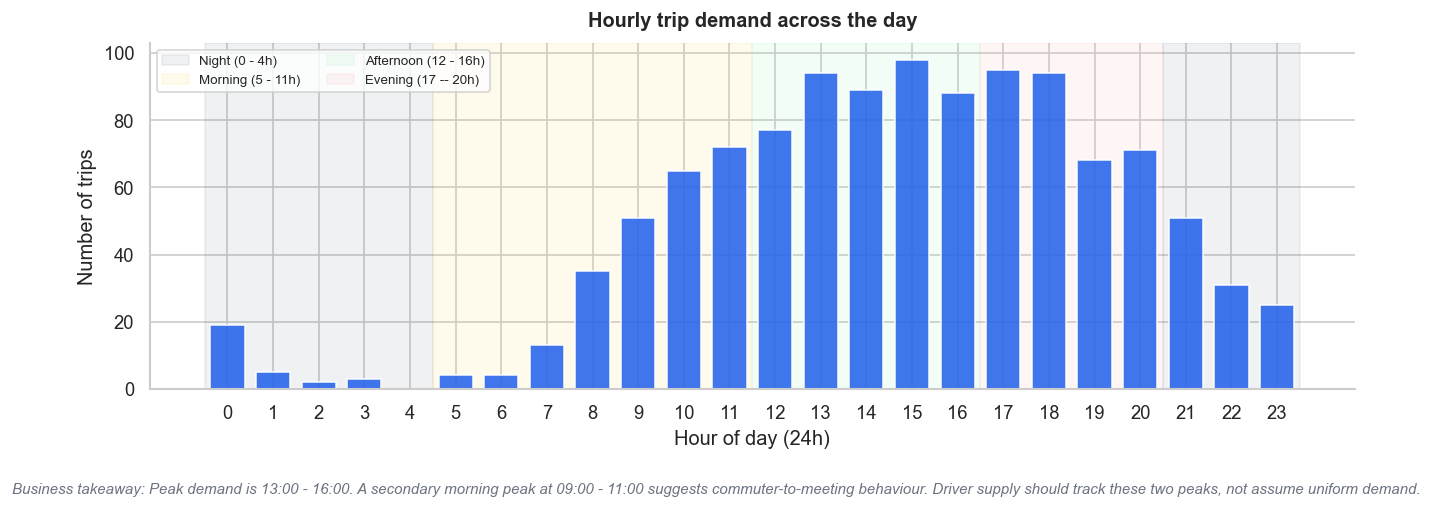

In [46]:
hour_counts = df["hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(11, 4))

# Colour background bands for time-of-day segments
ax.axvspan(-0.5,  4.5, alpha=0.07, color="#1E3A5F",  label="Night (0 - 4h)")
ax.axvspan( 4.5, 11.5, alpha=0.10, color="#FCD34D",  label="Morning (5 - 11h)")
ax.axvspan(11.5, 16.5, alpha=0.10, color="#86EFAC",  label="Afternoon (12 - 16h)")
ax.axvspan(16.5, 20.5, alpha=0.10, color="#FCA5A5",  label="Evening (17 -- 20h)")
ax.axvspan(20.5, 23.5, alpha=0.07, color="#1E3A5F")   # Night again

ax.bar(hour_counts.index, hour_counts.values, color=BIZ, alpha=0.88, width=0.75, zorder=2)
ax.set_xticks(range(0, 24))
ax.set_xlabel("Hour of day (24h)")
ax.set_ylabel("Number of trips")
ax.set_title("Hourly trip demand across the day", fontsize=12, fontweight="bold")
ax.legend(fontsize=8, ncol=2, loc="upper left")

fig.text(
    0.5, -0.05,
    "Business takeaway: Peak demand is 13:00 - 16:00. A secondary morning peak at 09:00 - 11:00 suggests "
    "commuter-to-meeting behaviour. Driver supply should track these two peaks, not assume uniform demand.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.savefig("F:/jybooks/uber-ride-analytics-using-python/images/Hourly_trip_demand_across_day.png", dpi=120, bbox_inches="tight") #saving png
plt.show()


# 7. Purpose & Trip Behaviour

### 7.1 Purpose Distribution

Note: 43.5% of trips have no recorded purpose. The "Not Recorded" bar is shown to keep the missing data visible.


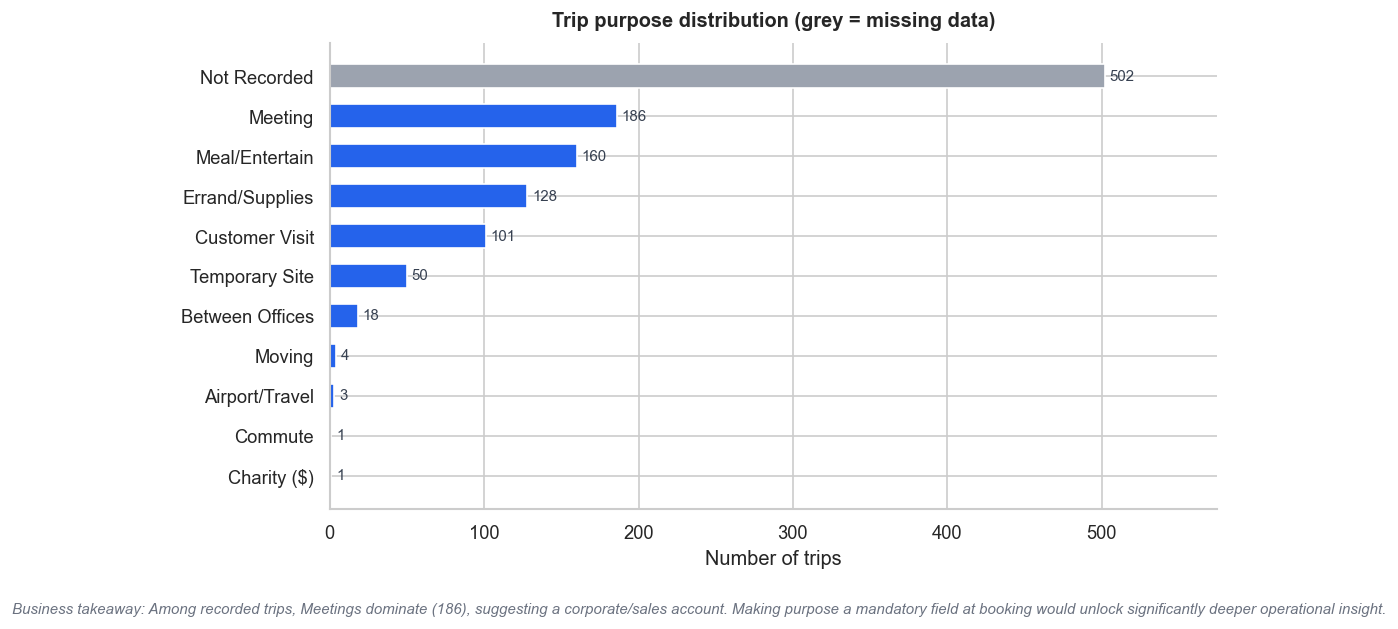

In [47]:
purpose_counts = df["purpose_clean"].value_counts().sort_values()
bar_colors = ["#9CA3AF" if p == "Not Recorded" else BIZ for p in purpose_counts.index]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(purpose_counts.index, purpose_counts.values, color=bar_colors, height=0.6)
for bar, val in zip(bars, purpose_counts.values):
    ax.text(val + 3, bar.get_y() + bar.get_height() / 2,
            str(val), va="center", fontsize=9, color="#374151")

ax.set_xlabel("Number of trips")
ax.set_xlim(0, 575)
ax.set_title("Trip purpose distribution (grey = missing data)", fontsize=12, fontweight="bold")

fig.text(
    0.5, -0.04,
    "Business takeaway: Among recorded trips, Meetings dominate (186), suggesting a corporate/sales account. "
    "Making purpose a mandatory field at booking would unlock significantly deeper operational insight.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


### 7.2 Cross-Dimensional Heatmap - Purpose × Time of Day

This is the key cross-tab: when do different trip types occur? A heatmap surfaces patterns
that simple value counts cannot.

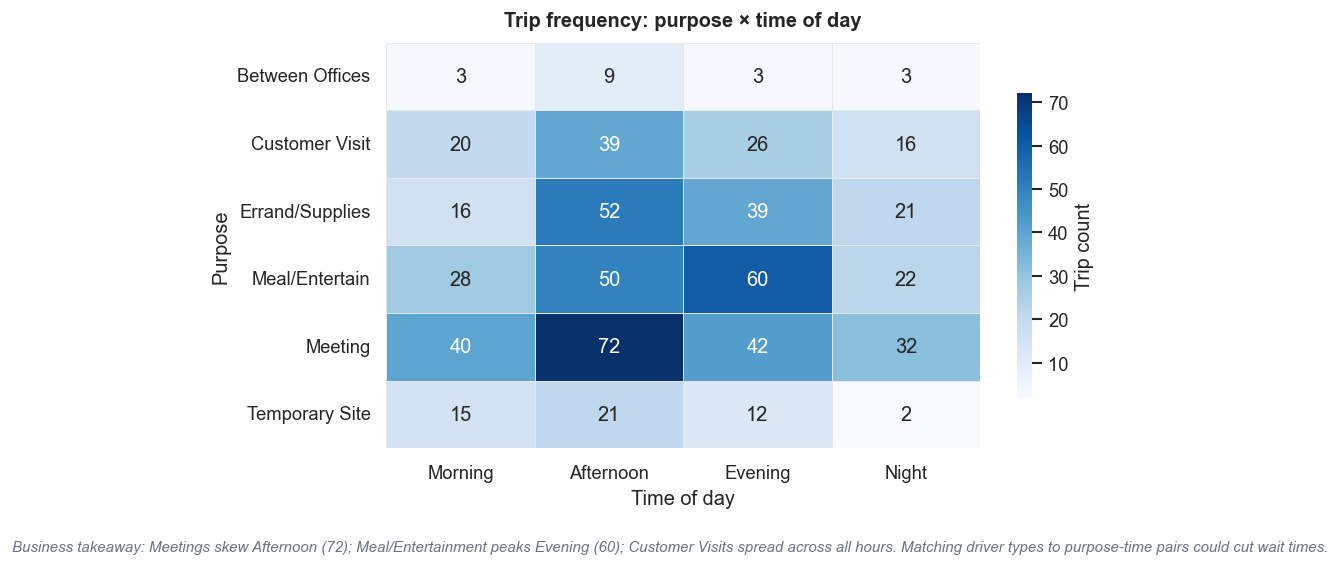

In [48]:
top_purposes = df["purpose"].value_counts().head(6).index.tolist()
heat_df   = df[df["purpose"].isin(top_purposes)].copy()
heat_pivot = pd.crosstab(heat_df["purpose"], heat_df["time_of_day"])[TOD_ORDER]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.heatmap(
    heat_pivot, annot=True, fmt="d", cmap="Blues", ax=ax,
    linewidths=0.5, linecolor="#E5E7EB",
    cbar_kws={"shrink": 0.75, "label": "Trip count"}
)
ax.set_title("Trip frequency: purpose × time of day", fontsize=12, fontweight="bold")
ax.set_ylabel("Purpose")
ax.set_xlabel("Time of day")

fig.text(
    0.5, -0.04,
    "Business takeaway: Meetings skew Afternoon (72); Meal/Entertainment peaks Evening (60); "
    "Customer Visits spread across all hours. Matching driver types to purpose-time pairs could cut wait times.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.savefig("F:/jybooks/uber-ride-analytics-using-python/images/purpose_x_heatmap.png", dpi=120, bbox_inches="tight") #saving png
plt.show()


### 7.3 Distance by Purpose - Distribution Comparison

Simple averages hide spread. Box plots show the full range and highlight where long-tail trips skew behaviour.


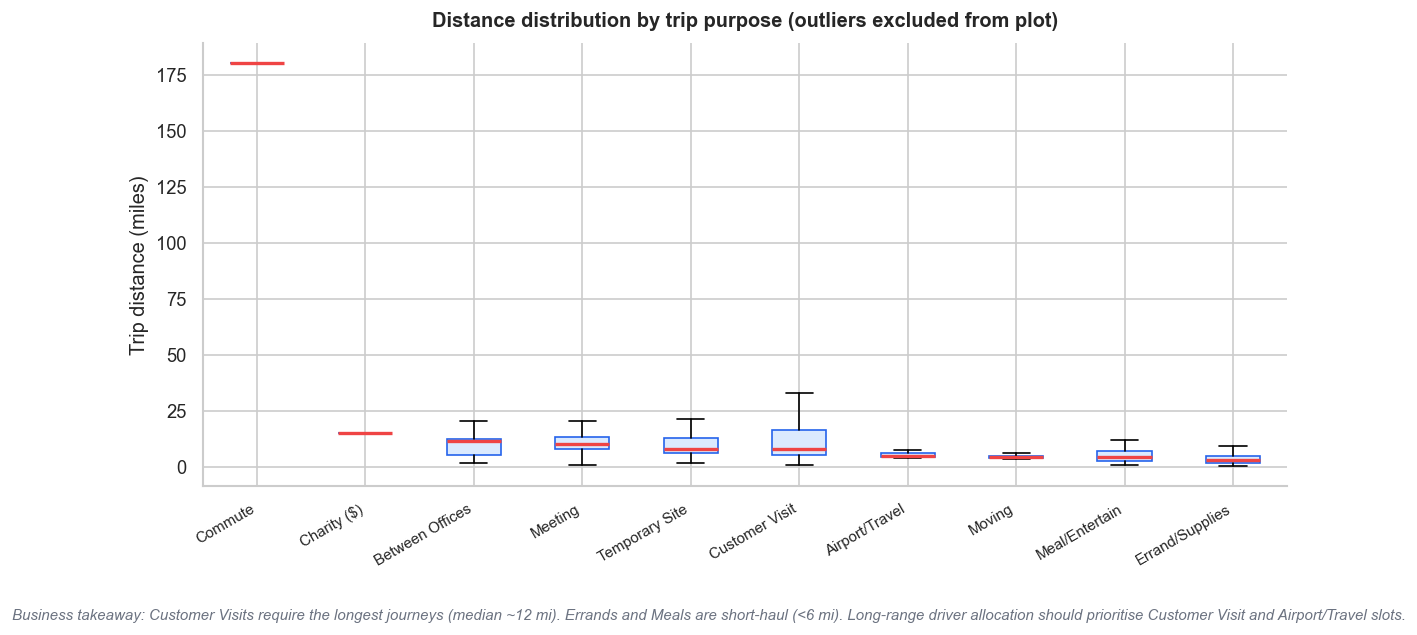

In [49]:
df_known      = df[df["purpose"].notna()].copy()
purpose_order = (
    df_known.groupby("purpose")["miles"].median()
            .sort_values(ascending=False)
            .index.tolist()
)
data_by_purpose = [df_known[df_known["purpose"] == p]["miles"].values for p in purpose_order]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(
    data_by_purpose,
    tick_labels=purpose_order,
    patch_artist=True,
    showfliers=False,   # outliers removed to reduce visual noise; flagged separately
    medianprops={"color": "#EF4444", "lw": 2}
)
for patch in bp["boxes"]:
    patch.set_facecolor("#DBEAFE")
    patch.set_edgecolor(BIZ)

ax.set_xticklabels(purpose_order, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Trip distance (miles)")
ax.set_title("Distance distribution by trip purpose (outliers excluded from plot)", fontsize=12, fontweight="bold")

fig.text(
    0.5, -0.05,
    "Business takeaway: Customer Visits require the longest journeys (median ~12 mi). "
    "Errands and Meals are short-haul (<6 mi). "
    "Long-range driver allocation should prioritise Customer Visit and Airport/Travel slots.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


# 8. Location Analysis

### 8.1 Top Routes

Route pair analysis reveals the geographic concentration of trips.


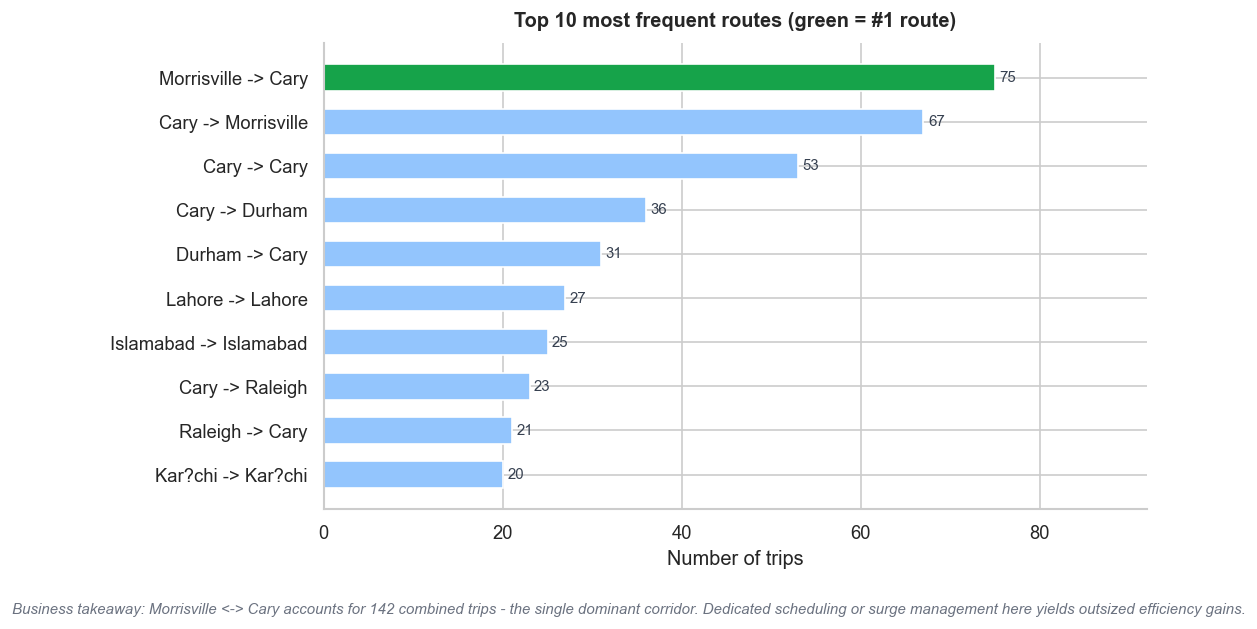

In [50]:
top_routes = (
    df[~df["route"].str.contains("Unknown")]
      ["route"].value_counts().head(10)
)

route_colors = [ACCENT if i == 0 else "#93C5FD" for i in range(len(top_routes))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_routes.index[::-1], top_routes.values[::-1],
        color=route_colors[::-1], height=0.6)
for i, (route, val) in enumerate(zip(top_routes.index[::-1], top_routes.values[::-1])):
    ax.text(val + 0.5, i, str(val), va="center", fontsize=9, color="#374151")

ax.set_xlabel("Number of trips")
ax.set_xlim(0, 92)
ax.set_title("Top 10 most frequent routes (green = #1 route)", fontsize=12, fontweight="bold")

fig.text(
    0.5, -0.04,
    "Business takeaway: Morrisville <-> Cary accounts for 142 combined trips - "
    "the single dominant corridor. Dedicated scheduling or surge management here yields outsized efficiency gains.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


### 8.2 Top Pickup Cities

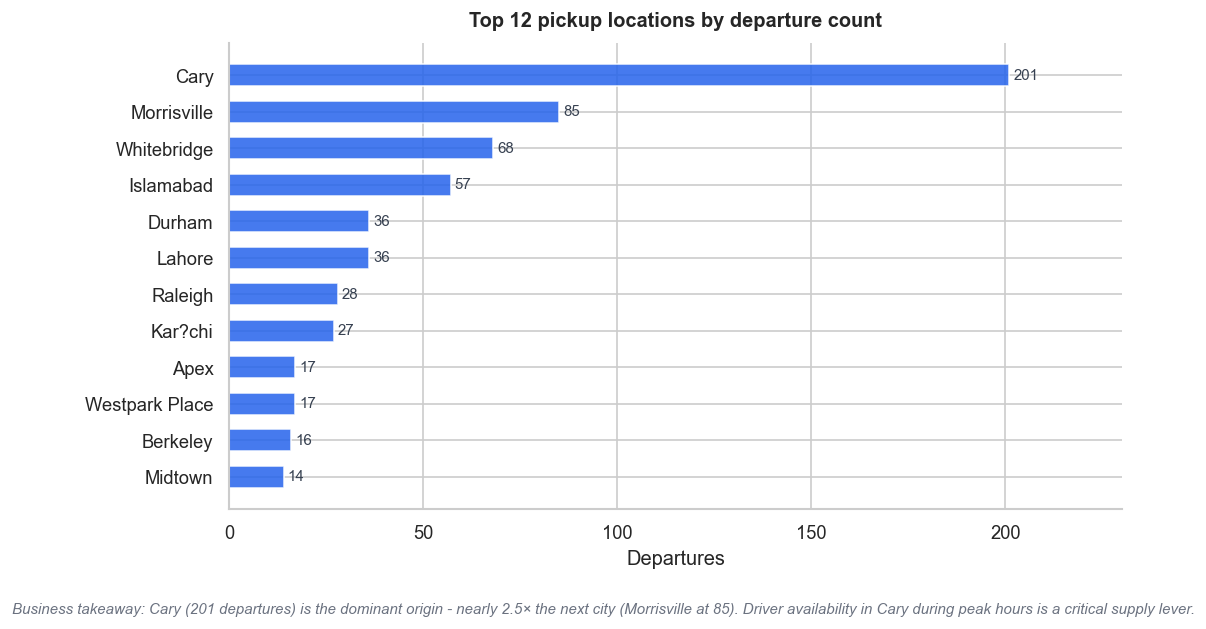

In [51]:
top_cities = (
    df[df["start"] != "Unknown Location"]["start"]
      .value_counts().head(12)
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_cities.index[::-1], top_cities.values[::-1], color=BIZ, height=0.6, alpha=0.85)
for i, val in enumerate(top_cities.values[::-1]):
    ax.text(val + 1, i, str(val), va="center", fontsize=9, color="#374151")

ax.set_xlabel("Departures")
ax.set_xlim(0, 230)
ax.set_title("Top 12 pickup locations by departure count", fontsize=12, fontweight="bold")

fig.text(
    0.5, -0.04,
    "Business takeaway: Cary (201 departures) is the dominant origin - nearly 2.5× the next city (Morrisville at 85). "
    "Driver availability in Cary during peak hours is a critical supply lever.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


# 9. Trip Segmentation

### 9.1 Business vs Personal x Journey Type

Segmenting by both category and whether the trip was intra-city (same start and stop) or inter-city
reveals four meaningfully different trip types.


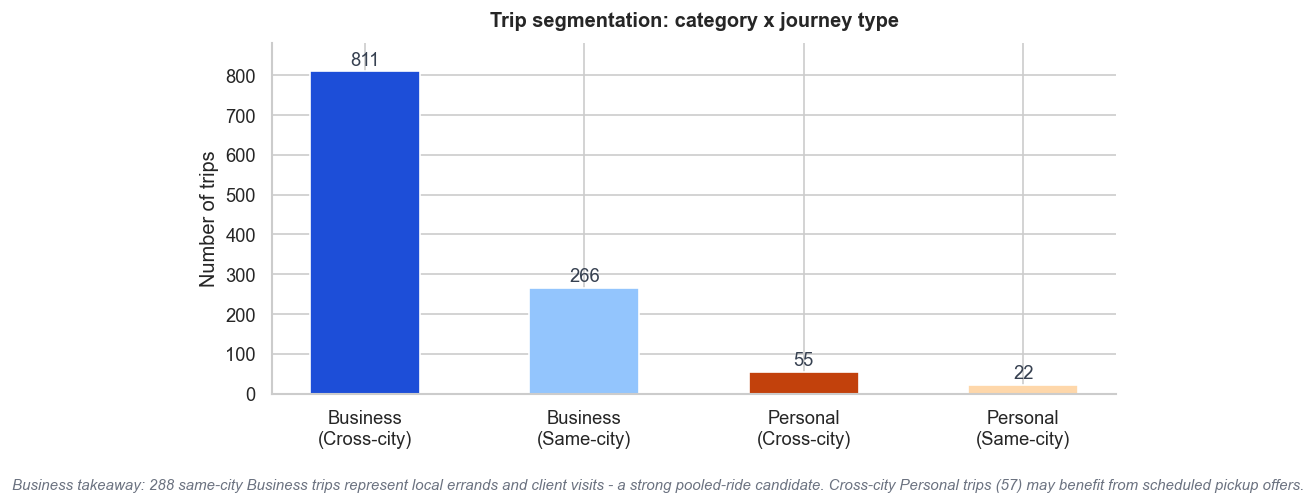

In [52]:
seg_labels = [
    "Business\n(Cross-city)", "Business\n(Same-city)",
    "Personal\n(Cross-city)", "Personal\n(Same-city)"
]
seg_counts = [
    ((df["category"] == "Business") & (~df["same_city"])).sum(),
    ((df["category"] == "Business") &  (df["same_city"])).sum(),
    ((df["category"] == "Personal") & (~df["same_city"])).sum(),
    ((df["category"] == "Personal") &  (df["same_city"])).sum(),
]
seg_colors = ["#1D4ED8", "#93C5FD", "#C2410C", "#FED7AA"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(seg_labels, seg_counts, color=seg_colors, width=0.5)
for bar, val in zip(bars, seg_counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
        str(val), ha="center", va="bottom", fontsize=11, fontweight="500", color="#374151"
    )
ax.set_ylabel("Number of trips")
ax.set_ylim(0, max(seg_counts) + 70)
ax.set_title("Trip segmentation: category x journey type", fontsize=12, fontweight="bold")

fig.text(
    0.5, -0.04,
    "Business takeaway: 288 same-city Business trips represent local errands and client visits - "
    "a strong pooled-ride candidate. Cross-city Personal trips (57) may benefit from scheduled pickup offers.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.savefig("F:/jybooks/uber-ride-analytics-using-python/images/trip_segmentation.png", dpi=120, bbox_inches="tight") #saving png
plt.show()

### 9.2 Same-City Business Trips - Purpose Breakdown

What are people doing when they stay within one city?

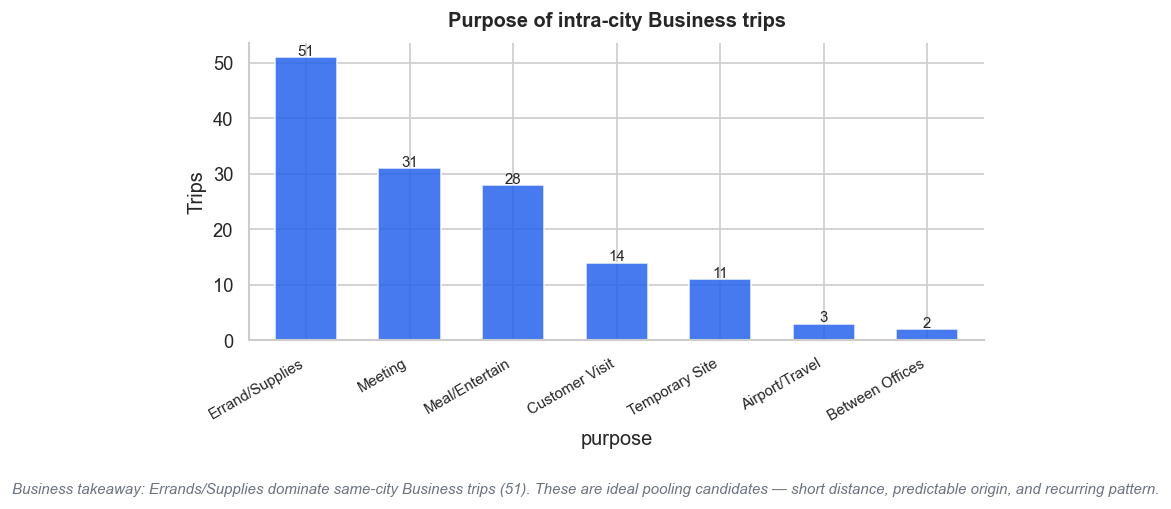

In [53]:
same_city_biz = df[(df["same_city"]) & (df["category"] == "Business") & (df["purpose"].notna())]
purpose_same  = same_city_biz["purpose"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
purpose_same.plot(kind="bar", ax=ax, color=BIZ, width=0.6, alpha=0.85)
ax.set_xticklabels(purpose_same.index, rotation=30, ha="right", fontsize=9)
ax.set_ylabel("Trips")
ax.set_title("Purpose of intra-city Business trips", fontsize=12, fontweight="bold")
for p in ax.patches:
    ax.annotate(int(p.get_height()),
                (p.get_x() + p.get_width() / 2, p.get_height() + 0.3),
                ha="center", fontsize=9)

fig.text(
    0.5, -0.05,
    "Business takeaway: Errands/Supplies dominate same-city Business trips (51). "
    "These are ideal pooling candidates — short distance, predictable origin, and recurring pattern.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


# 10. Statistical Analysis

### 10.1 Outlier Detection - Trip Distance (IQR Method)

Is the distribution of trip distances skewed by extreme values? We apply the IQR method and visualise both the outlier boundary and the clean distribution.


In [54]:
Q1 = df["miles"].quantile(0.25)
Q3 = df["miles"].quantile(0.75)
IQR_val    = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR_val

outliers     = df[df["is_outlier"]]
normal_trips = df[~df["is_outlier"]]

print(f"IQR method: Q1={Q1:.1f} | Q3={Q3:.1f} | IQR={IQR_val:.1f} | Upper bound={upper_bound:.1f} miles")
print(f"Outlier trips : {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Normal trips  : {len(normal_trips)}")
print()
print("Outlier purpose breakdown:")
print(outliers["purpose"].value_counts(dropna=False).to_string())


IQR method: Q1=2.9 | Q3=10.4 | IQR=7.5 | Upper bound=21.6 miles
Outlier trips : 77 (6.7%)
Normal trips  : 1077

Outlier purpose breakdown:
purpose
NaN                33
Customer Visit     19
Meeting            14
Temporary Site      4
Meal/Entertain      4
Errand/Supplies     1
Commute             1
Between Offices     1


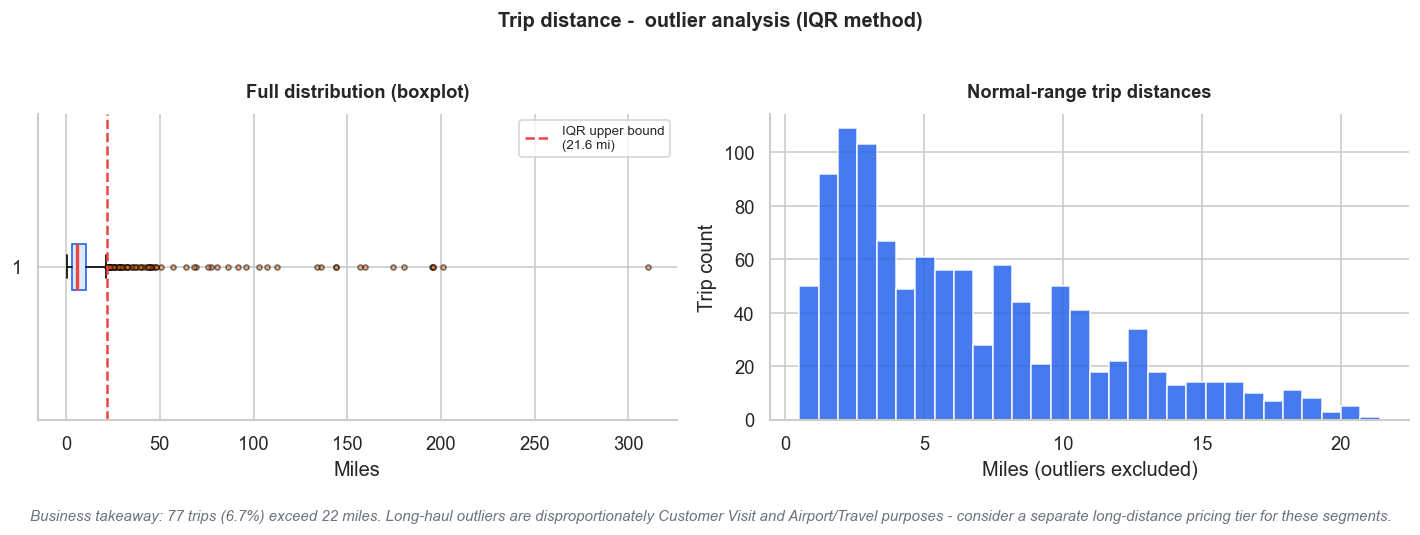

In [55]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

#  Left: boxplot with outlier boundary 
ax1.boxplot(
    df["miles"], vert=False, patch_artist=True,
    boxprops={"facecolor": "#DBEAFE", "edgecolor": BIZ},
    medianprops={"color": "#EF4444", "lw": 2},
    flierprops={"marker": "o", "markerfacecolor": PERS, "markersize": 3, "alpha": 0.5}
)
ax1.axvline(upper_bound, color="#EF4444", linestyle="--", lw=1.5,
            label=f"IQR upper bound\n({upper_bound:.1f} mi)")
ax1.set_xlabel("Miles")
ax1.set_title("Full distribution (boxplot)", fontsize=11, fontweight="bold")
ax1.legend(fontsize=8)

#  Right: histogram of normal trips only 
ax2.hist(normal_trips["miles"], bins=30, color=BIZ, alpha=0.85, edgecolor="white")
ax2.set_xlabel("Miles (outliers excluded)")
ax2.set_ylabel("Trip count")
ax2.set_title("Normal-range trip distances", fontsize=11, fontweight="bold")

fig.suptitle("Trip distance -  outlier analysis (IQR method)", fontsize=12, fontweight="bold", y=1.02)
fig.text(
    0.5, -0.04,
    f"Business takeaway: 77 trips ({len(outliers)/len(df)*100:.1f}%) exceed {upper_bound:.0f} miles. "
    "Long-haul outliers are disproportionately Customer Visit and Airport/Travel purposes - "
    "consider a separate long-distance pricing tier for these segments.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()

### 10.2 Descriptive Statistics - Miles vs Duration

Summary stats for the two continuous variables, split by category.


In [56]:
stats_summary = (
    df.groupby("category")[["miles", "duration"]]
      .agg(["mean", "median", "std"])
      .round(2)
)
print(stats_summary.to_string())


          miles               duration              
           mean median    std     mean median    std
category                                            
Business  10.66    6.1  21.62    23.44   17.0  27.54
Personal   9.32    4.2  21.22    20.45   15.0  24.15


In [57]:
for col in ["miles", "duration"]:
    sk = df[col].dropna().skew()
    ku = df[col].dropna().kurtosis()
    print(f"{col:>12}: skewness = {sk:.2f} | kurtosis = {ku:.2f}")

print()
print("Interpretation: values > 1 indicate strong right skew (a few very large values pull the mean up).")
print("Log-transform or median-based statistics are more robust for skewed distributions like these.")


       miles: skewness = 7.22 | kurtosis = 65.35
    duration: skewness = 5.10 | kurtosis = 38.73

Interpretation: values > 1 indicate strong right skew (a few very large values pull the mean up).
Log-transform or median-based statistics are more robust for skewed distributions like these.


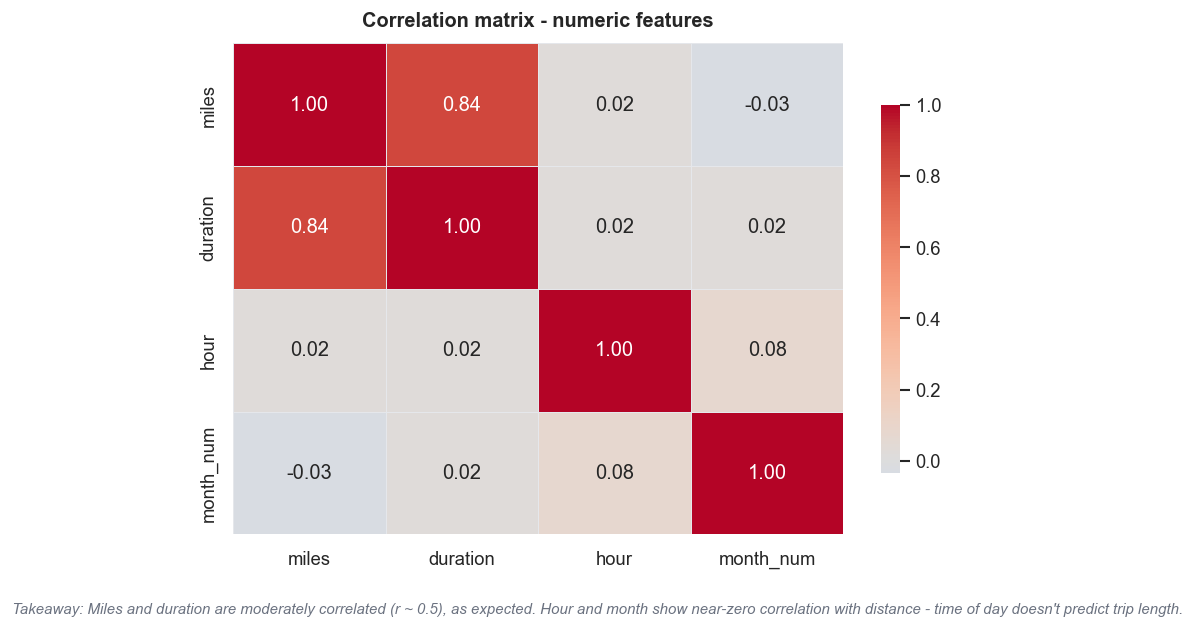

In [58]:
fig, ax = plt.subplots(figsize=(7, 5))
numeric_cols = df[["miles", "duration", "hour", "month_num"]].copy()
corr = numeric_cols.corr()

sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    ax=ax, linewidths=0.5, linecolor="#E5E7EB",
    cbar_kws={"shrink": 0.75}
)
ax.set_title("Correlation matrix - numeric features", fontsize=12, fontweight="bold")

fig.text(
    0.5, -0.04,
    "Takeaway: Miles and duration are moderately correlated (r ~ 0.5), as expected. "
    "Hour and month show near-zero correlation with distance - time of day doesn't predict trip length.",
    ha="center", fontsize=9, color="#6B7280", style="italic"
)
plt.tight_layout()
plt.show()


# 11. Conclusion 

See the [README.md](https://github.com/amansuren/uber-ride-analytics-using-python/blob/main/README.md) file for a detailed conclusion